In [1]:
%load_ext autoreload
%autoreload 2

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import h5py
from utils import get_eval_stats

In [136]:
target_protein=None
test_dir = "/home/shai/BLISS_Experiments/DRAKES/DRAKES/drakes_protein/fmif/eval_results/test/"
summary_func = np.mean

In [137]:
#################################

drakes_df = pd.read_csv(test_dir + "drakes_test.csv")
pretrained_df = pd.read_csv(test_dir + "pretrained_test.csv")

drakes_eval_stats = get_eval_stats(drakes_df, target_protein=target_protein, summary_func=summary_func)
pre_eval_stats = get_eval_stats(pretrained_df, target_protein=target_protein, summary_func=summary_func)

drakes_ddg_align = drakes_eval_stats['ddg_align']
pre_ddg_align = pre_eval_stats['ddg_align']

#################################

bon10_df = pd.read_csv(test_dir + "pretrained_test_ddg_bon_N=10.csv")
bon50_df = pd.read_csv(test_dir + "pretrained_test_ddg_bon_N=50.csv")

bon10_eval_stats = get_eval_stats(bon10_df, target_protein=target_protein, summary_func=summary_func)
bon50_eval_stats = get_eval_stats(bon50_df, target_protein=target_protein, summary_func=summary_func)

bon10_ddg_align = bon10_eval_stats['ddg_align']
bon50_ddg_align = bon50_eval_stats['ddg_align']

#################################

spec5_df = pd.read_csv(test_dir + "target/" + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=5.csv")
spec10_df = pd.read_csv(test_dir + "target/" + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10.csv")

spec5_eval_stats = get_eval_stats(spec5_df, target_protein=target_protein, summary_func=summary_func)
spec10_eval_stats = get_eval_stats(spec10_df, target_protein=target_protein, summary_func=summary_func)

spec5_ddg_align = spec5_eval_stats['ddg_align']
spec10_ddg_align = spec10_eval_stats['ddg_align']

#################################

In [138]:
# seq_recovery,seq,true_seq,protein_name,top_spec_interactions,spec_selections,spec_trajectory,r2_trajectory,loglikelihood,ddg,ddg_eval,scrmsd

In [168]:
def calc_avg_traj(df, traj_col, target_protein=None):
    if target_protein is not None:
        df = df[df['protein_name'] == target_protein + ".pdb"]
    
    trajectories = np.array([eval(lst) for lst in df[traj_col].tolist()])
    avg_traj = np.average(trajectories, axis=0)
    return avg_traj

def display_traj(df_lst, names, traj_col, ylabel, target_protein=None, ylim=None):
    trajectories = []
    for df in df_lst:
        avg_traj = calc_avg_traj(df, traj_col, target_protein=target_protein)
        trajectories.append(avg_traj)

    it_space = np.arange(trajectories[0].shape[0])

    for traj, name in zip(trajectories, names):
        plt.plot(it_space, traj, label=name)

    if traj_col == "spec_trajectory":
        plt.axhline(drakes_ddg_align, color='limegreen', linestyle='--', label='DRAKES', linewidth=1.25)
        plt.axhline(pre_ddg_align, color='dimgray', linestyle='--', label='Pretrained', linewidth=1.25)
        plt.axhline(bon50_ddg_align, color='deepskyblue', linestyle='--', label='BON50', linewidth=1.25)
        plt.axhline(bon10_ddg_align, color='lightblue', linestyle='--', label='BON10', linewidth=1.25)

    plt.xlabel("Feedback Iterations")
    plt.ylabel(ylabel)
    protein_info = "" if target_protein is None else f" {target_protein}"
    plt.title("Spectral Edit Position Reward Trajectories"+protein_info)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10, frameon=False)
    plt.xlim(it_space[0], it_space[-1])
    if ylim is not None:
        plt.ylim(ylim)
    plt.show()

In [170]:
dfs = [spec5_df, spec10_df]
names = ['Spec5', 'Spec10']

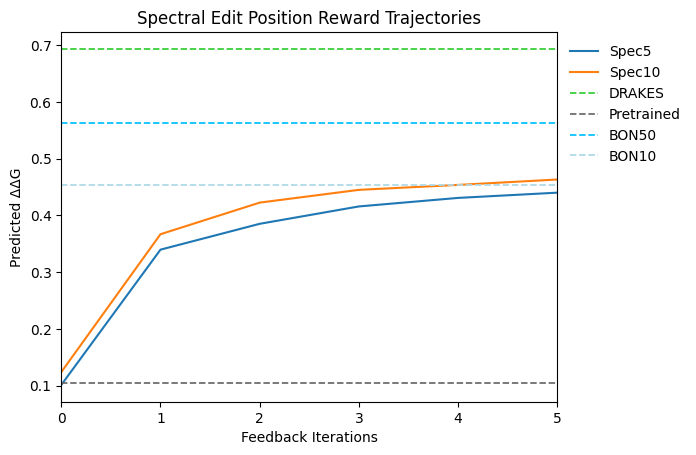

In [173]:
traj_col = 'spec_trajectory'
ylabel = "Predicted ΔΔG"
ylim = None

display_traj(dfs, names, traj_col, ylabel, ylim=ylim, target_protein=target_protein)

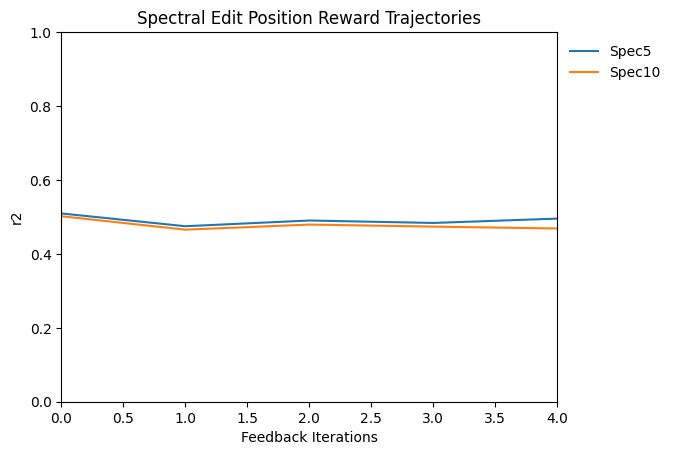

In [174]:
traj_col = 'r2_trajectory'
ylabel = "r2"
ylim = (0, 1)

display_traj(dfs, names, traj_col, ylabel, ylim=ylim, target_protein=target_protein)